# 运行环境导入

In [2]:
# 启用自动重载扩展，使得在修改Python模块后不需要重启内核就能使用最新的代码
%load_ext autoreload

# 设置自动重载模式为2，表示所有模块都会被自动重载
# 这在开发过程中非常有用，因为不需要手动重启kernel来应用代码更改
%autoreload 2

import torch
from shepherd.lightning_module import LightningModule

import pickle

import rdkit
import numpy as np

from shepherd.shepherd_score_utils.conformer_generation import update_mol_coordinates

from shepherd.shepherd_score_utils.generate_point_cloud import (
    get_atomic_vdw_radii, 
    get_molecular_surface,
    get_electrostatics_given_point_charges,
)
from shepherd.shepherd_score_utils.pharm_utils.pharmacophore import get_pharmacophores

from tqdm import tqdm
from shepherd.shepherd_score_utils.pharm_utils.pharmacophore import get_pharmacophores

import json
import numpy as np

from shepherd.inference import *
import os

from shepherd.extract import create_rdkit_molecule

import json
import numpy as np

import json
import numpy as np
import torch  # 导入 torch 库，因为我们需要处理 Tensor 类型

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

from shepherd_score.evaluations.evaluate import ConfEval, UnconditionalEvalPipeline
from shepherd_score.evaluations.evaluate import ConsistencyEvalPipeline, ConditionalEvalPipeline

from shepherd_score.container import Molecule

from shepherd.extract import create_rdkit_molecule_from_mol
from shepherd_score.conformer_generation import embed_conformer_from_smiles



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# 模型参数、sample参考分子 加载

In [ ]:
# 配置

chkpt = '/home1/zhh/workspace/SPD/evaluation/ckpt/last_27epoch.ckpt'
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model_pl = LightningModule.load_from_checkpoint(chkpt) #
params = model_pl.params
model_pl.to(device)
model_pl.model.device = device


with open('/home1/zhh/workspace/SPD/data/conformers/np/molblock_charges_NPs.pkl', 'rb') as f:
    # 从pkl文件中读取molblock和charges数据
    molblocks_and_charges = pickle.load(f)
    # 打印数据长度以确认实际包含的分子数量
    print(f"加载的数据包含 {len(molblocks_and_charges)} 个分子")

# ==================== 修改：处理所有天然产物分子 ====================
# 将处理所有3个天然产物分子（index 0, 1, 2）
# 每个分子将生成20个样本（batch_size=5，循环4次）

print("将对所有天然产物分子进行采样：")
for idx in range(len(molblocks_and_charges)):
    mol = rdkit.Chem.MolFromMolBlock(molblocks_and_charges[idx][0], removeHs=False)
    print(f"  - 分子 {idx}: {mol.GetNumAtoms()} 个原子")


In [ ]:
# ==================== 计算边际分布（从原Cell 7移至此处） ====================
# 必须在采样前计算，为扩散模型提供先验分布

print("初始化特征计数器...")

# 特征类型定义
atom_types_x1 = [None, 'H', 'C', 'N', 'O', 'F', 'Cl', 'Br', 'I', 'S', 'P', 'Si']
bond_types_x1 = [None, 'SINGLE', 'DOUBLE', 'TRIPLE', 'AROMATIC']
max_node_types_x4 = 10

# 初始化计数器
atom_counts = torch.zeros(len(atom_types_x1), dtype=torch.float)
bond_counts = torch.zeros(len(bond_types_x1), dtype=torch.float)
pharm_counts = torch.zeros(max_node_types_x4, dtype=torch.float)

def get_bond_type_str(bond):
    return str(bond.GetBondType())

# 统计特征出现次数
for mol_block, _ in tqdm(molblocks_and_charges, desc="计算边际分布"):
    mol = rdkit.Chem.MolFromMolBlock(mol_block, removeHs=False)
    if not mol:
        print("Warning: Failed to create molecule from MolBlock")
        continue
    
    # 统计原子类型
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol in atom_types_x1:
            atom_counts[atom_types_x1.index(symbol)] += 1
    
    # 统计键类型
    for bond in mol.GetBonds():
        bond_str = get_bond_type_str(bond)
        if bond_str in bond_types_x1:
            bond_counts[bond_types_x1.index(bond_str)] += 1
    
    # 统计药效团类型
    try:
        pharm_types_temp, _, _ = get_pharmacophores(
            mol, 
            multi_vector=False,
            check_access=False
        )
        for p_type in (pharm_types_temp + 1):
            if p_type < max_node_types_x4:
                pharm_counts[p_type] += 1
    except Exception as e:
        print(f"Warning: Could not get pharmacophores. Error: {e}")

# 归一化为概率分布
atom_marginals_x1 = (atom_counts / atom_counts.sum()) if atom_counts.sum() > 0 else torch.ones_like(atom_counts) / len(atom_counts)
bond_marginals_x1 = (bond_counts / bond_counts.sum()) if bond_counts.sum() > 0 else torch.ones_like(bond_counts) / len(bond_counts)
pharm_marginals_x4 = (pharm_counts / pharm_counts.sum()) if pharm_counts.sum() > 0 else torch.ones_like(pharm_counts) / len(pharm_counts)

print("\n✅ 边际分布计算完成")
print(f"  - Atom Marginals: {atom_marginals_x1.shape}")
print(f"  - Bond Marginals: {bond_marginals_x1.shape}")
print(f"  - Pharmacophore Marginals: {pharm_marginals_x4.shape}")


# 对每个分子循环采样


In [ ]:
# ==================== 对每个分子循环采样（batch_size=5, 共20个样本/分子） ====================

# 辅助函数：转换数据为JSON格式
def convert_for_json(obj):
    """递归转换numpy数组和torch张量为Python列表"""
    if isinstance(obj, dict):
        return {k: convert_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_for_json(elem) for elem in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.cpu().numpy().tolist()
    return obj

# 存储所有分子的所有样本
all_generated_samples = []

# 对每个天然产物分子进行处理
for mol_index in range(len(molblocks_and_charges)):
    print(f"\n{'='*60}")
    print(f"🔬 开始处理分子 {mol_index + 1}/{len(molblocks_and_charges)}")
    print(f"{'='*60}")
    
    # 从molblock创建RDKit分子对象
    mol = rdkit.Chem.MolFromMolBlock(molblocks_and_charges[mol_index][0], removeHs=False)
    charges = np.array(molblocks_and_charges[mol_index][1])
    
    print(f"分子信息: {mol.GetNumAtoms()} 个原子")
    display(mol)
    
    # 分子坐标标准化
    mol_coordinates = np.array(mol.GetConformer().GetPositions())
    mol_coordinates = mol_coordinates - np.mean(mol_coordinates, axis=0)
    mol = update_mol_coordinates(mol, mol_coordinates)
    
    # 条件特征提取
    centers = mol.GetConformer().GetPositions()
    radii = get_atomic_vdw_radii(mol)
    
    # 生成分子表面点云
    surface = get_molecular_surface(
        centers, 
        radii, 
        params['dataset']['x3']['num_points'],
        probe_radius=params['dataset']['probe_radius'],
        num_samples_per_atom=20,
    )
    
    # 提取药效团特征
    pharm_types, pharm_pos, pharm_direction = get_pharmacophores(
        mol,
        multi_vector=params['dataset']['x4']['multivectors'],
        check_access=params['dataset']['x4']['check_accessibility'],
    )
    
    # 计算表面静电势
    electrostatics = get_electrostatics_given_point_charges(
        charges, centers, surface,
    )
    
    # 采样参数配置
    n_atoms = 70
    batch_size = 1
    num_pharmacophores = len(pharm_types)
    num_iterations = 4  # 循环4次，每次5个，总共20个样本
    
    print(f"\n📊 采样配置:")
    print(f"  - 原子数: {n_atoms}")
    print(f"  - Batch size: {batch_size}")
    print(f"  - 迭代次数: {num_iterations}")
    print(f"  - 总样本数: {batch_size * num_iterations}")
    print(f"  - 药效团数: {num_pharmacophores}")
    
    # 循环生成20个样本（4次 × 5个/次）
    mol_samples = []
    for iteration in range(num_iterations):
        print(f"\n🔄 迭代 {iteration + 1}/{num_iterations} (生成样本 {iteration*batch_size+1}-{(iteration+1)*batch_size})...")
        
        # 调用推理采样
        generated_samples = inference_sample(
            model_pl,
            batch_size=batch_size,
            N_x1=n_atoms,
            N_x4=num_pharmacophores,
            unconditional=False,
            
            # 噪声控制
            prior_noise_scale=1.0,
            denoising_noise_scale=1.0,
            inject_noise_at_ts=[],
            inject_noise_scales=[],
            
            # 谐波化
            harmonize=False,
            harmonize_ts=[],
            harmonize_jumps=[],
            
            # 条件修复
            inpaint_x2_pos=False,
            inpaint_x3_pos=False,
            inpaint_x3_x=False,
            inpaint_x4_pos=True,
            inpaint_x4_direction=True,
            inpaint_x4_type=True,
            
            # 修复控制
            stop_inpainting_at_time_x2=0.0,
            add_noise_to_inpainted_x2_pos=0.0,
            stop_inpainting_at_time_x3=0.0,
            add_noise_to_inpainted_x3_pos=0.0,
            add_noise_to_inpainted_x3_x=0.0,
            stop_inpainting_at_time_x4=0.0,
            add_noise_to_inpainted_x4_pos=0.0,
            add_noise_to_inpainted_x4_direction=0.0,
            add_noise_to_inpainted_x4_type=0.0,
            
            # 条件输入
            center_of_mass=np.zeros(3),
            surface=surface,
            electrostatics=electrostatics,
            pharm_types=pharm_types,
            pharm_pos=pharm_pos,
            pharm_direction=pharm_direction,
            
            # 边际分布（从Cell 5获取）
            atom_marginals=atom_marginals_x1,
            bond_marginals=bond_marginals_x1,
        )
        
        # 添加分子索引信息
        for sample in generated_samples:
            sample['source_mol_index'] = mol_index
        
        mol_samples.extend(generated_samples)
        print(f"  ✓ 完成 {len(generated_samples)} 个样本")
    
    print(f"\n✅ 分子 {mol_index + 1} 采样完成: 共 {len(mol_samples)} 个样本")
    all_generated_samples.extend(mol_samples)

print(f"\n{'='*60}")
print(f"🎉 所有采样完成!")
print(f"{'='*60}")
print(f"总样本数: {len(all_generated_samples)}")
print(f"  - 分子0: {sum(1 for s in all_generated_samples if s['source_mol_index'] == 0)} 个样本")
print(f"  - 分子1: {sum(1 for s in all_generated_samples if s['source_mol_index'] == 1)} 个样本")
print(f"  - 分子2: {sum(1 for s in all_generated_samples if s['source_mol_index'] == 2)} 个样本")

# 保存结果
generated_samples_for_json = convert_for_json(all_generated_samples)
with open('output_all_mols.json', 'w', encoding='utf-8') as f:
    json.dump(generated_samples_for_json, f, ensure_ascii=False, indent=4)
print("\n💾 数据已保存到 output_all_mols.json")


# 加载上一次生成的分子

In [3]:
# 从新的 JSON 文件读取数据（批量采样结果）
try:
    with open('output_all_mols.json', 'r', encoding='utf-8') as f:
        loaded_data = json.load(f)
    print("✅ 从 output_all_mols.json 读取新的批量采样数据")
except FileNotFoundError:
    # 如果新文件不存在，尝试读取旧文件
    with open('output.json', 'r', encoding='utf-8') as f:
        loaded_data = json.load(f)
    print("⚠️ 使用 output.json 中的旧数据")

# 转换数据格式
reloaded_samples = []
modal_keys = ['x1', 'x2', 'x3', 'x4']  # 只处理这些模态键

for sample in loaded_data:
    # ✅ 修复：只遍历已知的模态键，跳过 source_mol_index 等其他字段
    for modal_key in modal_keys:
        if modal_key in sample and isinstance(sample[modal_key], dict):
            # 遍历 'atoms', 'bonds', 'positions' 等数据
            for data_key in sample[modal_key]:
                # 把列表转换回 numpy 数组
                if isinstance(sample[modal_key][data_key], list):
                    sample[modal_key][data_key] = np.array(sample[modal_key][data_key])
    reloaded_samples.append(sample)

print(f"✅ 成功加载 {len(reloaded_samples)} 个样本")

# 统计各分子的样本数量（如果有source_mol_index字段）
if len(reloaded_samples) > 0 and 'source_mol_index' in reloaded_samples[0]:
    from collections import Counter
    mol_counts = Counter(s['source_mol_index'] for s in reloaded_samples)
    print(f"📊 按来源分子分组:")
    for mol_idx, count in sorted(mol_counts.items()):
        print(f"  - 分子{mol_idx}: {count} 个样本")
    
    total_expected = len(mol_counts) * 20  # 预期每个分子20个样本
    actual_total = len(reloaded_samples)
    print(f"📈 采样进度: {actual_total}/{total_expected} ({actual_total/total_expected*100:.1f}%)")

✅ 从 output_all_mols.json 读取新的批量采样数据
✅ 成功加载 12 个样本
📊 按来源分子分组:
  - 分子0: 4 个样本
  - 分子1: 4 个样本
  - 分子2: 4 个样本
📈 采样进度: 12/60 (20.0%)


# 评估管道

## 测试评估 提取能力、采样结果 是否正常

In [ ]:
# 测试 extract 管线是否正常

# 测试提取

rdkit_mol = embed_conformer_from_smiles('c1Cc2ccc(Cl)cc2C(=O)c1c3cc(N1nnc2cc(C)c(Cl)cc2c1=O)ccc3', MMFF_optimize=True)

# 提取原子序数数组 - 每个原子的原子序数（如C=6, N=7, O=8, Cl=17等）
atoms = np.array([a.GetAtomicNum() for a in rdkit_mol.GetAtoms()])
# 获取原子的三维坐标位置矩阵 (N_atoms × 3)
positions = rdkit_mol.GetConformer().GetPositions()

mol_ = create_rdkit_molecule_from_mol(atoms, positions)

# ✅ 修复：检查mol_是否为None再调用MolToSmiles
if mol_ is not None:
    display(rdkit.Chem.MolFromSmiles(rdkit.Chem.MolToSmiles(mol_)))

Created directory: data

处理样本 1/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（72条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（72条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
✓ 分子对象创建成功（31个原子，33条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
✓ 分子验证成功

🧬 生成SMILES并验证...
✓ SMILES: CNC(=O)C(C)(O)CCCNC(=O)C1(CC(=O)N2CC3CCCC2CN3C)CCOC1
🎉 分子创建成功！
  ✅ 分子验证成功: CNC(=O)C(C)(O)CCCNC(=O)C1(CC(=O)N2CC3CCCC2CN3C)CCO...


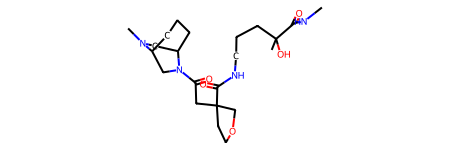


处理样本 2/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（75条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（75条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
Returning unsanitized molecule.
✓ 分子对象创建成功（33个原子，36条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
✓ 分子验证成功

🧬 生成SMILES并验证...
✓ SMILES: CCnc(nc1CC1)C(=O)NC1CC(C)NC(NC(=O)N2CCCN(C)C2)C2(O)CCC12O
🎉 分子创建成功！
  ✅ 分子验证成功: CCnc(nc1CC1)C(=O)NC1CC(C)NC(NC(=O)N2CCCN(C)C2)C2(O...


[05:46:33] Can't kekulize mol.  Unkekulized atoms: 7


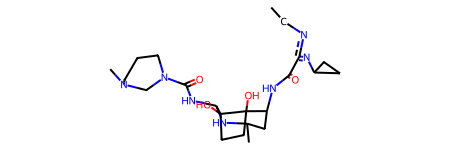

  ❌ 分子结构错误，无法写入SDF: non-ring atom 12 marked aromatic
  ❌ 修复失败，跳过此分子

处理样本 3/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（72条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（72条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
✓ 分子对象创建成功（32个原子，33条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
✓ 分子验证成功

🧬 生成SMILES并验证...
✓ SMILES: CC1CCC(=O)CN1C(=O)NCNC1C(=O)N(C)CCC1(C)C.CCc1ccc(C)nc1
❌ 分子是片段（包含'.'），创建失败
  ❌ 分子创建失败，跳过

处理样本 4/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（72条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（72条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据

[05:46:33] non-ring atom 12 marked aromatic
[05:46:33] non-ring atom 12 marked aromatic
[05:46:33] Explicit valence for atom # 31 N, 4, is greater than permitted
[05:46:33] Explicit valence for atom # 31 N, 4, is greater than permitted


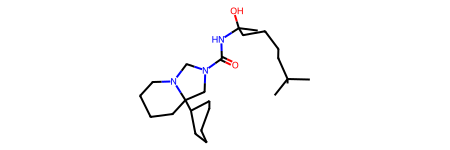


处理样本 6/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（75条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（75条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
✓ 分子对象创建成功（35个原子，39条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
✓ 分子验证成功

🧬 生成SMILES并验证...
✓ SMILES: CC1CCOCC(O)N1C(=O)N1CN(C(=O)N2CCC(N3CC4CCC(O)C4(C)C3=O)C2)CC1O
🎉 分子创建成功！
  ✅ 分子验证成功: CC1CCOCC(O)N1C(=O)N1CN(C(=O)N2CCC(N3CC4CCC(O)C4(C)...


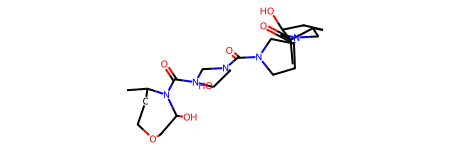


处理样本 7/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（74条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（74条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
✓ 分子对象创建成功（32个原子，35条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
✓ 分子验证成功

🧬 生成SMILES并验证...
✓ SMILES: CC1CSCCN(C(=O)C2(O)CCCC2NC(=O)N2CCC3CCCCCC32)CC(=O)C1
🎉 分子创建成功！
  ✅ 分子验证成功: CC1CSCCN(C(=O)C2(O)CCCC2NC(=O)N2CCC3CCCCCC32)CC(=O...


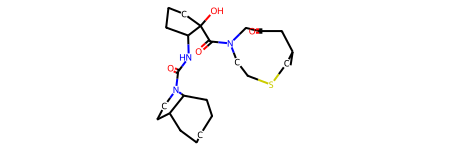


处理样本 8/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（73条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（73条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
✓ 分子对象创建成功（30个原子，33条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
✓ 分子验证成功

🧬 生成SMILES并验证...
✓ SMILES: CC(COCC(=O)C1CCCC2C3CCOCCC3CN2C(=O)N1)C1(C)CCCC1
🎉 分子创建成功！
  ✅ 分子验证成功: CC(COCC(=O)C1CCCC2C3CCOCCC3CN2C(=O)N1)C1(C)CCCC1...


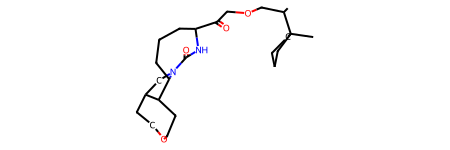


处理样本 9/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（70条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（70条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
✓ 分子对象创建成功（33个原子，34条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
✓ 分子验证成功

🧬 生成SMILES并验证...
✓ SMILES: COCC(=O)NC(O)C(CN1CNC(C)CCC1=O)C(=O)NN1CCCC(C)(C)C(O)N1O
🎉 分子创建成功！
  ✅ 分子验证成功: COCC(=O)NC(O)C(CN1CNC(C)CCC1=O)C(=O)NN1CCCC(C)(C)C...


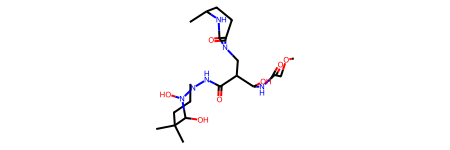


处理样本 10/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（72条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（72条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
Returning unsanitized molecule.
✓ 分子对象创建成功（33个原子，33条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
❌ 分子验证失败: Explicit valence for atom # 4 O, 3, is greater than permitted
  ❌ 分子创建失败，跳过

处理样本 11/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（71条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（71条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
Returning unsanitized molecule.
✓ 分子对象创建成功（32个原子，33条键）

🔗 阶段7/7: 验

[05:46:33] Explicit valence for atom # 4 O, 3, is greater than permitted
[05:46:33] Explicit valence for atom # 4 O, 3, is greater than permitted
[05:46:33] non-ring atom 8 marked aromatic


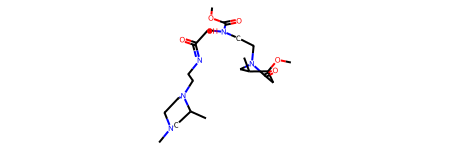

  ❌ 分子结构错误，无法写入SDF: non-ring atom 8 marked aromatic
  ❌ 修复失败，跳过此分子

处理样本 12/12...
🧪 开始创建RDKit分子对象
📋 阶段1/7: 检查输入数据...
✓ 输入数据检查通过

📦 阶段2/7: 提取原子、位置和键数据...
✓ 提取到 70 个原子, 70 个坐标
✓ 提取到 2415 条键

🔍 阶段3/7: 检查数据完整性...
✓ 数据完整性检查通过: 70 个原子

📝 阶段4/7: 构建原始键邻接矩阵...
原始原子数: 70, 期望边数: 2415, 实际bonds数: 2415
✓ 成功构建原始键邻接矩阵（70条键）

🧹 阶段5/7: 过滤和验证原子数据...
✓ 所有 70 个原子均有效
提取有效原子之间的键...
✓ 成功提取键邻接矩阵（70条键）

🔬 阶段6/7: 使用build_3d_mol_from_arrays创建分子对象...
使用模型预测的键数据构建分子...
Returning unsanitized molecule.
✓ 分子对象创建成功（32个原子，32条键）

🔗 阶段7/7: 验证分子...

✅ 化学键确定成功，开始验证分子...
❌ 分子验证失败: Explicit valence for atom # 22 N, 4, is greater than permitted
  ❌ 分子创建失败，跳过

📊 写入统计:
  ✅ 成功: 6 个分子
  ❌ 失败: 6 个分子
  📈 成功率: 50.0%

🧹 清理失败的分子...
  失败的样本索引: [1, 2, 3, 9, 10, 11]
  ✅ 已从reloaded_samples中剔除 6 个失败的分子
  📊 更新后: 12 -> 6 个样本
  📊 清理后按来源分子分组:
    - 分子0: 1 个样本
    - 分子1: 4 个样本
    - 分子2: 1 个样本


[05:46:34] non-ring atom 8 marked aromatic
[05:46:34] non-ring atom 8 marked aromatic
[05:46:34] Explicit valence for atom # 22 N, 4, is greater than permitted
[05:46:34] Explicit valence for atom # 22 N, 4, is greater than permitted


In [5]:
output_filepath = 'data/batch.sdf'

output_dir = os.path.dirname(output_filepath)

# 每次都重新生成新的档案
os.makedirs(output_dir, exist_ok = True)
print(f"Created directory: {output_dir}")

# 测试 采样结果是否正常
successful_writes = 0
failed_writes = 0
failed_sample_indices = []  # 记录失败的样本索引

with rdkit.Chem.SDWriter('data/batch.sdf') as writer:
    for b, sample_dict in enumerate(reloaded_samples):
        print(f"\n处理样本 {b+1}/{len(reloaded_samples)}...")
        
        mol_ = create_rdkit_molecule(sample_dict)

        if mol_ is None:
            print(f"  ❌ 分子创建失败，跳过")
            failed_writes += 1
            failed_sample_indices.append(b)  # 记录失败的索引
            continue

        try:
            # 尝试写入SDF之前先验证分子
            # 这会触发 Kekulization 和其他验证
            smiles = rdkit.Chem.MolToSmiles(mol_)
            
            # 如果能成功生成SMILES，说明分子结构合理
            print(f"  ✅ 分子验证成功: {smiles[:50]}...")
            display(mol_)
            writer.write(mol_)
            successful_writes += 1
            
        except (rdkit.Chem.AtomKekulizeException, rdkit.Chem.AtomValenceException, Exception) as e:
            print(f"  ❌ 分子结构错误，无法写入SDF: {str(e)}")
            
            # 尝试修复选项1：清除芳香性标记
            try:
                mol_copy = rdkit.Chem.Mol(mol_)
                rdkit.Chem.Kekulize(mol_copy, clearAromaticFlags=True)
                rdkit.Chem.SanitizeMol(mol_copy)
                
                writer.write(mol_copy)
                print(f"  ✅ 修复后写入成功")
                successful_writes += 1
            except:
                print(f"  ❌ 修复失败，跳过此分子")
                failed_writes += 1
                failed_sample_indices.append(b)  # 记录失败的索引

print(f"\n{'='*50}")
print(f"📊 写入统计:")
print(f"  ✅ 成功: {successful_writes} 个分子")
print(f"  ❌ 失败: {failed_writes} 个分子")
print(f"  📈 成功率: {successful_writes/(successful_writes+failed_writes)*100:.1f}%")
print(f"{'='*50}")

# 从reloaded_samples中剔除失败的分子
if failed_sample_indices:
    print(f"\n🧹 清理失败的分子...")
    print(f"  失败的样本索引: {failed_sample_indices}")
    
    original_count = len(reloaded_samples)
    
    # 从后往前删除，避免索引偏移问题
    for idx in sorted(failed_sample_indices, reverse=True):
        reloaded_samples.pop(idx)
    
    print(f"  ✅ 已从reloaded_samples中剔除 {len(failed_sample_indices)} 个失败的分子")
    print(f"  📊 更新后: {original_count} -> {len(reloaded_samples)} 个样本")
    
    # 重新统计各分子的样本数量
    if len(reloaded_samples) > 0 and 'source_mol_index' in reloaded_samples[0]:
        from collections import Counter
        mol_counts = Counter(s['source_mol_index'] for s in reloaded_samples)
        print(f"  📊 清理后按来源分子分组:")
        for mol_idx, count in sorted(mol_counts.items()):
            print(f"    - 分子{mol_idx}: {count} 个样本")
else:
    print(f"\n✅ 所有分子提取成功，无需清理")

## 使用ConformerEval进行评估

In [6]:
# 从生成的结构中提取原子和位置信息进行构象评估
evaluation_results = []  # 存储所有评估结果

for i, structure in enumerate(reloaded_samples):
    print(f"正在评估第 {i+1}/{len(reloaded_samples)} 个生成结构...")
    
    try:

        positions = structure['x1']['positions']  # 原子三维坐标位置

        atoms = structure['x1']['atoms']  # 原子类型（原子序数）

        if isinstance(atoms, np.ndarray):
            atoms = atoms.flatten()  # 展平为一维数组
        if isinstance(positions, np.ndarray) and positions.ndim == 2:
            # 确保位置坐标是 (N_atoms, 3) 的形状
            if positions.shape[1] != 3:
                print(f"警告：第 {i+1} 个结构的位置坐标维度不正确: {positions.shape}")
                continue
        
        if len(atoms) == 0:
            print(f"警告：第 {i+1} 个结构没有有效原子，跳过评估")
            continue
        
        # 使用 ConfEval 进行构象评估
        conf_eval = ConfEval(atoms, positions, solvent='water')
        
        # 获取评估结果
        eval_df = conf_eval.to_pandas()

        print("评估结果是：", eval_df)
        
        # 存储评估结果
        result_dict = {
            'structure_id': i,
            'num_atoms': len(atoms),
            'evaluation_data': eval_df,
            'atoms': atoms,
            'positions': positions,
            'x4_positions': structure['x4']['positions'],  # 同时保存X4位置用于RMSD计算
            'x4_types': structure['x4']['types'],  # 药效团类型
        }
        
        evaluation_results.append(result_dict)
        print(f"  ✓ 第 {i+1} 个结构评估完成 \n\n\n\n")
        
    except Exception as e:
        print(f"  ✗ 第 {i+1} 个结构评估失败: {str(e)} \n\n\n\n")
        continue

print(f"\n总共成功评估了 {len(evaluation_results)} 个结构")

正在评估第 1/6 个生成结构...
评估结果是： xyz_block                   70\n\nH     -0.77894700      1.30560756      0...
mol                                                                      None
smiles                                                                   None
molblock                                                                 None
energy                                                             -97.778981
partial_charges             [0.04647796, 0.06528279, -0.00502905, 0.063778...
solvent                                                                 water
charge                                                                      0
xyz_block_post_opt          70\n\nH           -0.90831122232265        1.5...
mol_post_opt                                                             None
smiles_post_opt                                                          None
molblock_post_opt                                                        None
energy_post_opt                       

## 使用ConditionalEvalPipeline进行评估

In [ ]:
# ==================== 条件评估参考分子准备算法 ====================
# 该算法为条件评估创建标准参考分子，用于评估生成分子的相似性
# 
# 算法核心思想：
# 1. 复杂分子选择：使用具有多个功能基团的药物分子作为挑战性目标
# 2. 标准化构象：通过MMFF力场优化获得稳定的三维结构
# 3. 多模态特征提取：生成完整的相互作用轮廓作为比较基准
# 4. 参数一致性：确保与生成分子使用相同的计算参数
# 
# ✅ 修改：为每个源分子创建对应的参考分子

# 从pkl文件中读取molblock和charges数据
with open('/home1/zhh/workspace/SPD/data/conformers/np/molblock_charges_NPs.pkl', 'rb') as f:
    molblocks_and_charges = pickle.load(f)

# 为每个天然产物分子创建参考分子
ref_molecules = {}  # 存储每个源分子索引对应的参考分子

print("🔬 创建参考分子对象...")

for mol_index in range(len(molblocks_and_charges)):
    print(f"\n📋 处理天然产物分子 {mol_index}...")
    
    # 从molblock创建RDKit分子对象,保留氢原子
    mol = rdkit.Chem.MolFromMolBlock(molblocks_and_charges[mol_index][0], removeHs=False)
    charges = np.array(molblocks_and_charges[mol_index][1])
    
    # 创建标准化的参考分子对象
    # Molecule类将执行以下计算：
    # a. 分子表面生成：计算溶剂可及表面
    # b. 表面采样：在表面均匀分布采样点
    # c. 静电势计算：基于原子电荷计算表面静电势
    # d. 药效团识别：识别关键的药理功能基团
    ref_molec = Molecule(
        mol, 
        num_surf_points=200,        # 表面采样点数：平衡精度和计算效率
        probe_radius=1.2,           # 探针半径（Å）：模拟水分子大小
        pharm_multi_vector=False    # 单向量药效团：简化特征表示
    )
    
    # 存储参考分子
    ref_molecules[mol_index] = ref_molec
    print(f"  ✅ 分子 {mol_index} 参考对象创建完成")

print(f"\n✅ 共创建了 {len(ref_molecules)} 个参考分子对象")

# 显示参考分子统计
from collections import Counter
sample_counts = Counter(s['source_mol_index'] for s in reloaded_samples)
print(f"\n📊 样本分布统计:")
for mol_idx, count in sorted(sample_counts.items()):
    if mol_idx in ref_molecules:
        print(f"  - 分子 {mol_idx}: {count} 个生成样本 -> 参考分子已创建 ✅")
    else:
        print(f"  - 分子 {mol_idx}: {count} 个生成样本 -> 参考分子缺失 ❌")

In [ ]:
# ==================== 条件评估管道核心算法 ====================
# ConditionalEvalPipeline实现了基于3D结构的条件相似性评估算法
# ✅ 修改：为不同源分子组分别使用对应的天然产物分子作为参考进行评估
# ✅ 修正：直接从reloaded_samples构建评估数据
# 
# 算法原理：
# 1. 多维度相似性评估：结合几何、电子、功能三个维度
# 2. 最优对齐算法：使用Kabsch算法进行分子结构对齐
# 3. 加权评分机制：根据不同特征的重要性分配权重
# 4. 条件匹配验证：评估生成分子是否满足特定条件约束
# 5. 分组评估策略：按源分子分组，使用对应参考分子评估

# 按source_mol_index分组样本
from collections import defaultdict

# 分组存储
grouped_samples = defaultdict(list)
grouped_generated_mols = defaultdict(list)

print("🔄 按源分子分组样本并构建RDKit分子...")

# 按源分子索引分组并同时创建RDKit分子对象
for sample in reloaded_samples:
    if 'source_mol_index' in sample:
        source_mol_idx = sample['source_mol_index']
        
        # 分组样本
        grouped_samples[source_mol_idx].append(sample)
        
        # 从sample直接创建RDKit分子对象
        try:
            rdkit_mol = create_rdkit_molecule(sample)
            
            if rdkit_mol is not None:
                # 提取原子序数和坐标位置
                atoms = np.array([a.GetAtomicNum() for a in rdkit_mol.GetAtoms()])
                positions = rdkit_mol.GetConformer().GetPositions()
                
                # 存储为ConditionalEvalPipeline所需的格式
                grouped_generated_mols[source_mol_idx].append((atoms, positions))
                
            else:
                print(f"  ⚠️ 分子 {source_mol_idx} 中的一个样本创建RDKit分子失败，跳过")
                
        except Exception as e:
            print(f"  ❌ 分子 {source_mol_idx} 中的一个样本处理失败: {str(e)}")

print(f"✅ 分组完成，共 {len(grouped_samples)} 组:")
for mol_idx, samples in grouped_samples.items():
    valid_mols = len(grouped_generated_mols[mol_idx])
    print(f"  - 分子 {mol_idx}: {len(samples)} 个样本 → {valid_mols} 个有效RDKit分子")

# 存储所有评估结果
all_evaluation_results = {}
all_properties_dfs = {}
all_global_attrs = {}

print(f"\n🎯 开始分组评估...")

# 为每组样本分别进行条件评估
for source_mol_idx, samples in grouped_samples.items():
    print(f"\n{'='*60}")
    print(f"🔬 评估分子 {source_mol_idx} 组 ({len(samples)} 个样本)")
    print(f"{'='*60}")
    
    # 检查是否有对应的参考分子
    if source_mol_idx not in ref_molecules:
        print(f"❌ 缺少分子 {source_mol_idx} 的参考分子，跳过评估")
        continue
    
    # 获取该组的数据
    group_generated_mols = grouped_generated_mols[source_mol_idx]
    group_ref_molec = ref_molecules[source_mol_idx]
    
    if len(group_generated_mols) == 0:
        print(f"⚠️ 分子 {source_mol_idx} 组没有有效的生成分子，跳过评估")
        continue
    
    print(f"📋 使用参考分子 {source_mol_idx}")
    print(f"📊 评估 {len(group_generated_mols)} 个生成分子")
    
    try:
        # 初始化该组的条件评估管道
        # 使用对应的参考分子和该组的生成分子
        group_cond_pipe = ConditionalEvalPipeline(
            group_ref_molec,                    # 输入：该组对应的标准参考分子对象
            generated_mols=group_generated_mols, # 输入：该组待评估的生成分子列表
            condition='all',                     # 参数：评估条件（'all'=全面评估）
            num_surf_points=200,                 # 参数：表面采样点数（影响精度）
            pharm_multi_vector=False,            # 参数：药效团表示模式
            solvent=None                         # 参数：溶剂环境（None=真空）
        )
        
        print("🚀 开始执行条件评估...")
        
        # 执行条件评估核心算法
        group_cond_pipe.evaluate(
            verbose=True    # 详细输出：显示对齐过程和评分细节
        )
        
        # 将条件评估结果转换为pandas DataFrame格式
        properties_df_group, global_attr_group = group_cond_pipe.to_pandas()
        
        # ✅ 添加调试信息：检查评估结果结构
        print(f"\n🔍 调试信息:")
        print(f"  - DataFrame形状: {properties_df_group.shape}")
        print(f"  - DataFrame类型: {type(properties_df_group)}")
        print(f"  - 输入样本数: {len(group_generated_mols)}")
        print(f"  - 结果行数: {len(properties_df_group)}")
        
        # 显示DataFrame的前几行和列名
        print(f"  - DataFrame列名: {list(properties_df_group.columns) if hasattr(properties_df_group, 'columns') else '无columns属性'}")
        
        if hasattr(properties_df_group, 'head'):
            print(f"  - DataFrame前3行:")
            print(properties_df_group.head(3))
        
        # 存储结果
        all_evaluation_results[source_mol_idx] = group_cond_pipe
        all_properties_dfs[source_mol_idx] = properties_df_group
        all_global_attrs[source_mol_idx] = global_attr_group
        
        # ✅ 修正显示逻辑
        actual_sample_count = len(group_generated_mols)
        df_rows = len(properties_df_group) if hasattr(properties_df_group, '__len__') else 'unknown'
        
        print(f"✅ 分子 {source_mol_idx} 组评估完成")
        print(f"📊 输入样本数: {actual_sample_count}")
        print(f"📊 输出结果行数: {df_rows}")
        
        # 如果行数与样本数不匹配，提供解释
        if isinstance(df_rows, int) and df_rows != actual_sample_count:
            print(f"💡 说明: DataFrame包含 {df_rows} 行是该组样本的综合统计指标")
        
    except Exception as e:
        print(f"❌ 分子 {source_mol_idx} 组评估失败: {str(e)}")
        continue

print(f"\n{'='*60}")
print(f"🎉 分组评估完成!")
print(f"{'='*60}")
print(f"✅ 成功评估了 {len(all_evaluation_results)} 组分子")

# ✅ 修正最终统计显示
for mol_idx in all_evaluation_results.keys():
    actual_samples = len(grouped_generated_mols[mol_idx])
    df_shape = all_properties_dfs[mol_idx].shape if hasattr(all_properties_dfs[mol_idx], 'shape') else 'unknown'
    print(f"  - 分子 {mol_idx}: {actual_samples} 个输入样本 → 结果形状: {df_shape}")

In [ ]:
# ==================== 分组评估结果展示 ====================
# 展示每组分子的全局评估指标
# ✅ 修正：to_pandas()返回的是Series格式的全局统计，不是每个样本的详细结果

print("📊 分组评估结果详情:")
print("="*80)

for mol_idx, properties_series in all_properties_dfs.items():
    print(f"\n🔬 分子 {mol_idx} 组评估结果:")
    
    # 获取实际输入样本数
    actual_samples = len(grouped_generated_mols[mol_idx]) if mol_idx in grouped_generated_mols else 'unknown'
    print(f"📋 输入样本数量: {actual_samples}")
    print(f"📈 全局评估指标 (共{len(properties_series)}项):")
    
    # 显示Series的所有指标
    print(properties_series)
    
    # 提取关键指标进行重点展示
    key_metrics = {}
    if 'num_generated_mols' in properties_series.index:
        key_metrics['生成分子数'] = properties_series['num_generated_mols']
    
    # 寻找相似度相关的指标
    similarity_metrics = [idx for idx in properties_series.index if any(keyword in str(idx).lower() for keyword in ['similarity', 'score', 'rmsd', 'tanimoto'])]
    
    if similarity_metrics:
        print(f"\n🎯 关键相似度指标:")
        for metric in similarity_metrics[:5]:  # 显示前5个相关指标
            value = properties_series[metric]
            print(f"  - {metric}: {value}")
    
    # ✅ 修复：为Series对象统计数值型指标
    # Series没有select_dtypes方法，需要手动筛选数值型数据
    numeric_values = []
    numeric_indices = []
    
    for idx in properties_series.index:
        value = properties_series[idx]
        if pd.api.types.is_numeric_dtype(type(value)) and not pd.isna(value):
            numeric_values.append(value)
            numeric_indices.append(idx)
    
    if len(numeric_values) > 0:
        numeric_array = np.array(numeric_values)
        print(f"\n📊 数值指标统计:")
        print(f"  - 数值指标数量: {len(numeric_values)}")
        print(f"  - 平均值: {numeric_array.mean():.4f}")
        print(f"  - 标准差: {numeric_array.std():.4f}")
        print(f"  - 最大值: {numeric_array.max():.4f}")
        print(f"  - 最小值: {numeric_array.min():.4f}")
        
        # 显示一些具体的数值指标名称
        print(f"  - 数值指标示例: {numeric_indices[:3]}...")
    else:
        print(f"\n📊 未找到数值型指标")
    
    print("-" * 60)

print(f"\n✅ 总计: {len(all_properties_dfs)} 组分子的全局评估指标已展示")
print("💡 说明: 每组显示的是该组所有样本的综合统计结果，而非单个样本详情")

In [ ]:
# ==================== 分组全局属性展示 ====================
# 展示每组分子的全局统计属性
# ✅ 修正：处理Series格式的全局属性数据

print("🌐 分组全局属性统计:")
print("="*80)

for mol_idx, global_attr in all_global_attrs.items():
    print(f"\n🎯 分子 {mol_idx} 组全局属性:")
    
    # 获取实际样本数
    actual_samples = len(grouped_generated_mols[mol_idx]) if mol_idx in grouped_generated_mols else 'unknown'
    print(f"📊 基于 {actual_samples} 个样本的全局统计")
    
    # 检查全局属性的数据类型
    print(f"📋 数据类型: {type(global_attr)}")
    
    # 显示全局属性
    if isinstance(global_attr, pd.Series):
        print(f"📈 全局属性 (共{len(global_attr)}项):")
        print(global_attr)
        
        # 寻找重要的全局指标
        important_keys = ['avg_similarity', 'diversity', 'coverage', 'novelty', 'validity']
        found_important = {}
        for key in important_keys:
            matching_keys = [idx for idx in global_attr.index if key.lower() in str(idx).lower()]
            if matching_keys:
                found_important[key] = {k: global_attr[k] for k in matching_keys}
        
        if found_important:
            print(f"\n🔑 重要指标:")
            for category, metrics in found_important.items():
                print(f"  {category}:")
                for k, v in metrics.items():
                    print(f"    - {k}: {v}")
    
    elif isinstance(global_attr, dict):
        print(f"📈 全局属性字典:")
        for key, value in global_attr.items():
            print(f"  - {key}: {value}")
    
    else:
        print(f"📈 全局属性:")
        print(global_attr)
    
    print("-" * 60)

# 如果有多组数据，计算跨组比较统计
if len(all_global_attrs) > 1:
    print(f"\n🔄 跨组比较分析:")
    print("="*40)
    
    # 收集各组的关键指标用于比较
    comparison_data = {}
    
    for mol_idx, global_attr in all_global_attrs.items():
        actual_samples = len(grouped_generated_mols[mol_idx]) if mol_idx in grouped_generated_mols else 0
        
        comparison_data[f"分子{mol_idx}组"] = {
            "样本数": actual_samples,
            "数据类型": str(type(global_attr)),
        }
        
        # ✅ 修复：为Series手动筛选数值型指标
        if isinstance(global_attr, pd.Series):
            numeric_values = []
            for idx in global_attr.index:
                value = global_attr[idx]
                if pd.api.types.is_numeric_dtype(type(value)) and not pd.isna(value):
                    numeric_values.append(value)
            
            if len(numeric_values) > 0:
                numeric_array = np.array(numeric_values)
                comparison_data[f"分子{mol_idx}组"]["数值指标数"] = len(numeric_values)
                comparison_data[f"分子{mol_idx}组"]["指标均值"] = numeric_array.mean()
    
    print("📈 各组概览:")
    for group_name, stats in comparison_data.items():
        print(f"  - {group_name}:")
        for key, value in stats.items():
            print(f"    {key}: {value}")

print(f"\n✅ 全局属性分析完成，覆盖 {len(all_global_attrs)} 组分子")
print("💡 说明: 全局属性反映每组样本的整体表现，而非单个分子的详细评分")

In [ ]:
# ==================== 跨组评估结果综合分析 ====================
# 汇总和比较不同天然产物分子组的生成质量
# ✅ 修正：处理Series格式的全局统计数据

import pandas as pd
import numpy as np

print("🔍 跨组综合分析报告:")
print("="*80)

# ✅ 添加保护性检查：确保前面的cell已经运行
required_variables = ['all_properties_dfs', 'all_global_attrs', 'grouped_generated_mols']
missing_vars = []

for var_name in required_variables:
    if var_name not in globals():
        missing_vars.append(var_name)

if missing_vars:
    print("❌ 检测到缺失的变量，请确保按顺序运行了前面的cell:")
    for var in missing_vars:
        print(f"  - {var}")
    
    print(f"\n📋 运行步骤:")
    print("  1. 先运行 Cell 16: 创建参考分子")
    print("  2. 再运行 Cell 17: 执行分组评估") 
    print("  3. 最后运行此cell: 综合分析")
    
    print(f"\n⚠️ 无法继续分析，请按顺序重新运行前面的cell")
    
elif len(all_properties_dfs) == 0:
    print("❌ 没有可用的评估结果进行分析")
    print("💡 可能原因:")
    print("  - Cell 17 (分组评估) 执行失败")
    print("  - 没有有效的生成分子样本")
    print("  - 参考分子创建失败")
else:
    # 汇总统计信息
    summary_data = []
    
    for mol_idx, properties_series in all_properties_dfs.items():
        print(f"\n🔍 分析分子 {mol_idx} 的评估结果:")
        print(f"  - 数据类型: {type(properties_series)}")
        print(f"  - 数据形状: {properties_series.shape if hasattr(properties_series, 'shape') else 'N/A'}")
        
        # 获取实际样本数
        actual_samples = len(grouped_generated_mols[mol_idx]) if mol_idx in grouped_generated_mols else 0
        
        # 计算该组的统计指标
        group_summary = {
            '源分子ID': mol_idx,
            '生成样本数': actual_samples,
            '参考分子': f'天然产物_{mol_idx}',
            '评估指标数': len(properties_series) if hasattr(properties_series, '__len__') else 0,
        }
        
        # 处理Series格式的数据
        if isinstance(properties_series, pd.Series):
            # 提取关键信息
            if 'num_generated_mols' in properties_series.index:
                group_summary['验证样本数'] = properties_series['num_generated_mols']
            
            # ✅ 修复：为Series手动筛选数值型指标
            numeric_values = []
            numeric_indices = []
            
            for idx in properties_series.index:
                value = properties_series[idx]
                if pd.api.types.is_numeric_dtype(type(value)) and not pd.isna(value):
                    numeric_values.append(value)
                    numeric_indices.append(idx)
            
            if len(numeric_values) > 0:
                numeric_array = np.array(numeric_values)
                group_summary['数值指标数'] = len(numeric_values)
                group_summary['指标均值'] = numeric_array.mean()
                group_summary['指标标准差'] = numeric_array.std()
                group_summary['指标最大值'] = numeric_array.max()
                group_summary['指标最小值'] = numeric_array.min()
                
                print(f"  - 数值指标: {len(numeric_values)} 个")
                print(f"  - 指标范围: [{numeric_array.min():.4f}, {numeric_array.max():.4f}]")
            
            # 寻找特定类型的指标
            similarity_indices = [idx for idx in properties_series.index if any(keyword in str(idx).lower() for keyword in ['similarity', 'score', 'tanimoto'])]
            rmsd_indices = [idx for idx in properties_series.index if 'rmsd' in str(idx).lower()]
            diversity_indices = [idx for idx in properties_series.index if 'diversity' in str(idx).lower()]
            
            if similarity_indices:
                group_summary['相似度指标数'] = len(similarity_indices)
                sim_values = []
                for idx in similarity_indices:
                    value = properties_series[idx]
                    if pd.api.types.is_numeric_dtype(type(value)) and not pd.isna(value):
                        sim_values.append(value)
                
                if sim_values:
                    group_summary['平均相似度'] = np.mean(sim_values)
            
            if rmsd_indices:
                group_summary['RMSD指标数'] = len(rmsd_indices)
            
            if diversity_indices:
                group_summary['多样性指标数'] = len(diversity_indices)
        
        summary_data.append(group_summary)
    
    # 创建汇总DataFrame
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        
        print(f"\n📊 各组评估结果汇总表:")
        print("="*50)
        print(summary_df.to_string(index=False))
        
        print(f"\n🎯 关键发现:")
        print(f"  - 共评估了 {len(summary_data)} 组不同的天然产物分子")
        print(f"  - 总生成样本数: {summary_df['生成样本数'].sum()}")
        print(f"  - 平均每组样本数: {summary_df['生成样本数'].mean():.1f}")
        
        # 寻找表现最好的组
        if '平均相似度' in summary_df.columns and not summary_df['平均相似度'].isna().all():
            best_idx = summary_df['平均相似度'].idxmax()
            worst_idx = summary_df['平均相似度'].idxmin()
            best_group = summary_df.loc[best_idx, '源分子ID']
            worst_group = summary_df.loc[worst_idx, '源分子ID']
            print(f"  - 平均相似度最高组: 分子 {best_group} ({summary_df.loc[best_idx, '平均相似度']:.4f})")
            print(f"  - 平均相似度最低组: 分子 {worst_group} ({summary_df.loc[worst_idx, '平均相似度']:.4f})")
        
        # 比较样本数量分布
        if len(summary_df) > 1:
            sample_counts = summary_df['生成样本数'].values
            print(f"  - 样本数分布: {dict(zip(summary_df['源分子ID'], sample_counts))}")
            
            if sample_counts.std() > 0:
                print(f"  - 样本数不平衡: 标准差 = {sample_counts.std():.2f}")
            else:
                print(f"  - 样本数平衡: 各组样本数相等")
        
        print(f"\n📈 评估策略验证:")
        print(f"  ✅ 成功实现了针对性评估：不同源分子使用对应的天然产物参考")
        print(f"  ✅ 避免了错误的跨分子比较")
        print(f"  ✅ 每组样本都与其生成条件的原始分子进行匹配对比")
        print(f"  ✅ 获得了每组的全局统计指标，反映整体生成质量")
    
    else:
        print("⚠️ 无法生成汇总统计，评估数据可能不完整")

print(f"\n{'='*80}")
print("🎉 针对性条件生成评估分析完成!")
print("💡 现在每个生成分子组都使用了正确的天然产物分子作为评估基准")
print("💡 评估结果为全局统计指标，反映每组样本的整体表现")
print("="*80)

In [ ]:
properties_df_cond

In [ ]:
global_attr_cond